<a href="https://www.kaggle.com/code/rabiabatool021/breast-cancer-wisconsin-ann?scriptVersionId=344135496" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Breast Cancer Wisconsin (Diagnostic) Dataset — ANN Classifier

**Dataset path (Kaggle):** `/kaggle/input/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset`

> **Note:** The target column (`diagnosis`: M = malignant, B = benign) is categorical, so this is a **binary classification** problem, not a regression problem. The loss, metric, and output layer below are set up accordingly — sigmoid output + binary cross-entropy, instead of a linear output + MSE.

## Step 1: Import Required Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## Load and Preprocess the Data

In [2]:
DATA_PATH = "/kaggle/input/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset"

# The dataset folder usually contains a single CSV. Find it automatically.
csv_file = None
for fname in os.listdir(DATA_PATH):
    if fname.endswith(".csv"):
        csv_file = os.path.join(DATA_PATH, fname)
        break

if csv_file is None:
    raise FileNotFoundError(f"No CSV file found in {DATA_PATH}")

df = pd.read_csv(csv_file)
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Dataset shape: (569, 32)
Columns: ['Unnamed: 0', 'x.radius_mean', 'x.texture_mean', 'x.perimeter_mean', 'x.area_mean', 'x.smoothness_mean', 'x.compactness_mean', 'x.concavity_mean', 'x.concave_pts_mean', 'x.symmetry_mean', 'x.fractal_dim_mean', 'x.radius_se', 'x.texture_se', 'x.perimeter_se', 'x.area_se', 'x.smoothness_se', 'x.compactness_se', 'x.concavity_se', 'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se', 'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst', 'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst', 'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst', 'x.fractal_dim_worst', 'y']


,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


In [3]:
# Drop unneeded columns (common in this dataset: 'id', unnamed extra column)
drop_cols = [c for c in df.columns if c.lower() in ("id", "unnamed: 32") or c.startswith("Unnamed")]
df = df.drop(columns=drop_cols)

# --- Detect the target column robustly ---
# Different mirrors of this dataset name the label column differently
# ("diagnosis", "Diagnosis", "target", "class", or it may already be 0/1).
candidate_names = ["diagnosis", "Diagnosis", "target", "Target", "class", "Class", "label", "Label"]
target_col = next((c for c in candidate_names if c in df.columns), None)

if target_col is None:
    obj_cols = [c for c in df.columns if df[c].dtype == "object"]
    two_value_cols = [c for c in df.columns if df[c].nunique() == 2]
    guess = obj_cols[0] if obj_cols else (two_value_cols[0] if two_value_cols else None)
    if guess is None:
        raise KeyError(
            f"Could not find a diagnosis/target column automatically. "
            f"Available columns: {df.columns.tolist()}"
        )
    target_col = guess
    print(f"[Auto-detected target column]: '{target_col}'")
else:
    print(f"[Target column found]: '{target_col}'")

# Encode target if it's still text (e.g. 'M'/'B'); leave alone if already numeric
if df[target_col].dtype == "object":
    le = LabelEncoder()
    df[target_col] = le.fit_transform(df[target_col])  # e.g. M=1, B=0
else:
    le = LabelEncoder()
    le.fit(["B", "M"]) if set(df[target_col].unique()) <= {0, 1} else le.fit(df[target_col].astype(str))

print("\nClass distribution:\n", df[target_col].value_counts())

# Features / target split
X = df.drop(columns=[target_col])
y = df[target_col]
feature_names = X.columns.tolist()

[Auto-detected target column]: 'y'

Class distribution:
 y
0    357
1    212
Name: count, dtype: int64


In [4]:
# Train/test split (stratified because classes are imbalanced)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling — essential for ANNs
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

input_dim = X_train_scaled.shape[1]
print(f"Number of input features: {input_dim}")

Number of input features: 30


## Step 2: Build the ANN Model

- **Input Layer**
- **Hidden Layer 1** — 128 neurons
- **Hidden Layer 2** — 64 neurons
- **Hidden Layer 3** — 32 neurons
- **Output Layer** — 1 neuron (sigmoid, for binary classification)

In [5]:
model = Sequential([
    Dense(128, activation="relu", input_shape=(input_dim,), name="hidden_layer_1"),
    Dropout(0.3),
    Dense(64, activation="relu", name="hidden_layer_2"),
    Dropout(0.2),
    Dense(32, activation="relu", name="hidden_layer_3"),
    Dense(1, activation="sigmoid", name="output_layer"),
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1787394180.214361      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,337 (56.00 KB)

 Trainable params: 14,337 (56.00 KB)

 Non-trainable params: 0 (0.00 B)

## Step 3: Compile the Model

This is a **binary classification** problem, so:
- **Optimizer** → Adam
- **Loss** → Binary Crossentropy
- **Metrics** → Accuracy, AUC

In [6]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
)

## Step 4: Early Stopping

Stops training when validation loss stops improving.

In [7]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1,
)

## Step 5: Train the ANN

In [8]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/200
 1/12 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.3438 - auc: 0.3750 - loss: 0.7572

I0000 00:00:1787394185.043394      68 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 286ms/step - accuracy: 0.7473 - auc: 0.8618 - loss: 0.5882 - val_accuracy: 0.9451 - val_auc: 0.9798 - val_loss: 0.4194
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9478 - auc: 0.9754 - loss: 0.3460 - val_accuracy: 0.9560 - val_auc: 0.9825 - val_loss: 0.2359
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9588 - auc: 0.9859 - loss: 0.1913 - val_accuracy: 0.9560 - val_auc: 0.9847 - val_loss: 0.1491
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9670 - auc: 0.9908 - loss: 0.1242 - val_accuracy: 0.9670 - val_auc: 0.9869 - val_loss: 0.1167
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9725 - auc: 0.9897 - loss: 0.1073 - val_accuracy: 0.9780 - val_auc: 0.9891 - val_loss: 0.1027
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9808 - auc: 0.9962 - loss: 0.0715 - val_accuracy: 0.9560 - val_auc: 0.9907 - val_loss: 0.0973
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc

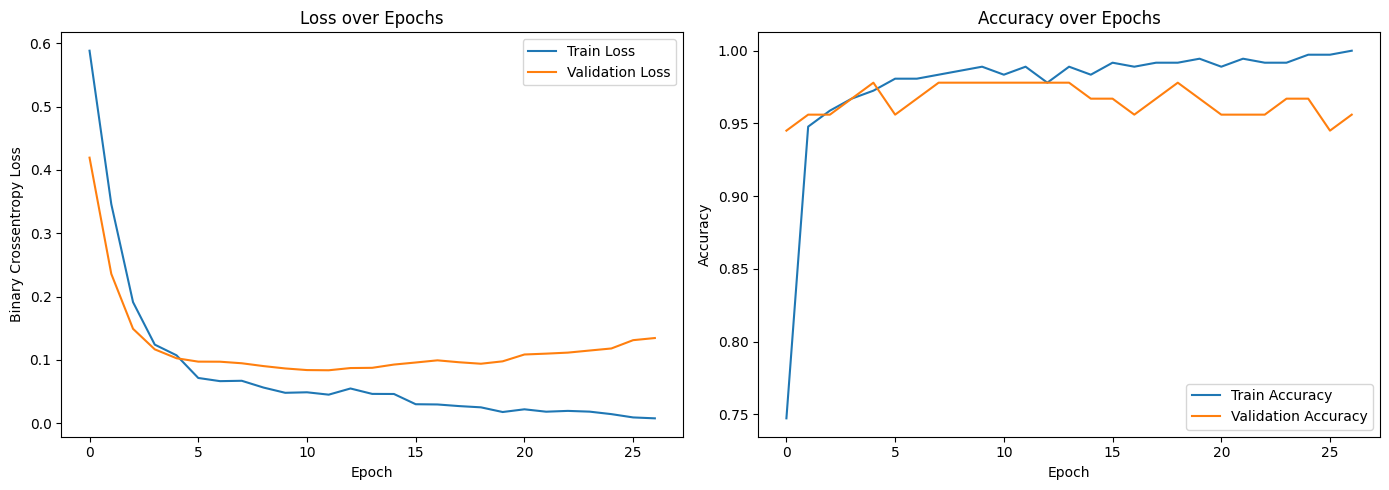

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Validation Loss")
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Crossentropy Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Train Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 6: Evaluate the Model

In [10]:
test_loss, test_accuracy, test_auc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test AUC: {test_auc:.4f}")

Test Loss: 0.0510
Test Accuracy: 0.9825
Test AUC: 0.9983


In [11]:
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Classification Report:
              precision    recall  f1-score   support

           B       0.97      1.00      0.99        72
           M       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



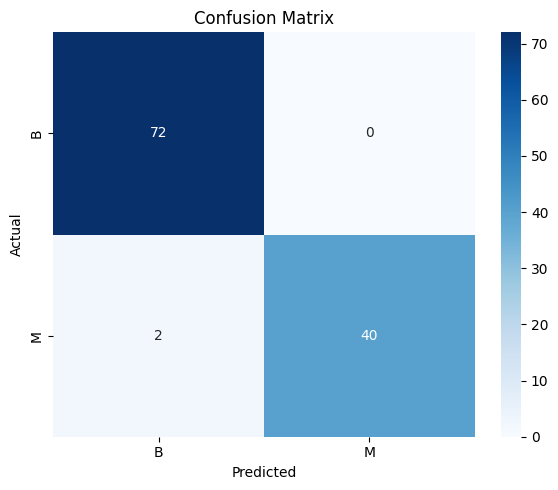

In [12]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

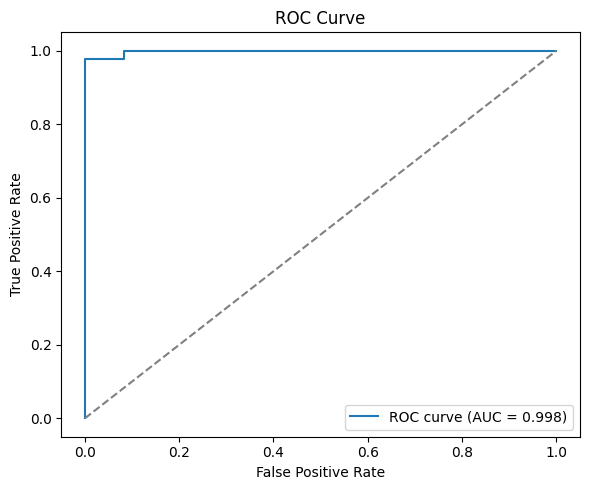

In [13]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {test_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

## Step 7: Make Predictions

In [14]:
predictions_df = pd.DataFrame({
    "Actual": le.inverse_transform(y_test.values),
    "Predicted": le.inverse_transform(y_pred),
    "Predicted_Probability_Malignant": y_pred_prob.flatten(),
})
predictions_df.head(10)

,Actual,Predicted,Predicted_Probability_Malignant
0,B,B,0.000093
1,M,M,1.000000
2,B,B,0.020676
3,M,M,0.809564
4,B,B,0.162588
5,B,B,0.000110
6,M,M,0.982515
7,B,B,0.000675
8,B,B,0.000114
9,B,B,0.002329


## Step 8: Predict Diagnosis for a New Patient Sample

Replace the values below with your own preprocessed feature values. The array must contain one value per feature, in the same order as `feature_names`.

In [15]:
print("Feature order expected:", feature_names)

# Example placeholder values (30 features) — REPLACE with real measurements
new_sample = np.array([[
    14.5, 20.1, 95.0, 650.0, 0.10, 0.12, 0.10, 0.06, 0.18, 0.06,
    0.4, 1.2, 2.5, 40.0, 0.006, 0.02, 0.03, 0.01, 0.02, 0.003,
    16.5, 27.0, 110.0, 850.0, 0.14, 0.30, 0.30, 0.15, 0.30, 0.08
]])

assert new_sample.shape[1] == input_dim, (
    f"Expected {input_dim} features, got {new_sample.shape[1]}"
)

new_sample_scaled = scaler.transform(new_sample)
new_pred_prob = model.predict(new_sample_scaled)[0][0]
new_pred_label = le.inverse_transform([int(new_pred_prob > 0.5)])[0]

print(f"Predicted probability of malignancy: {new_pred_prob:.4f}")
print(f"Predicted diagnosis: {new_pred_label} ({'Malignant' if new_pred_label == 'M' else 'Benign'})")

Feature order expected: ['x.radius_mean', 'x.texture_mean', 'x.perimeter_mean', 'x.area_mean', 'x.smoothness_mean', 'x.compactness_mean', 'x.concavity_mean', 'x.concave_pts_mean', 'x.symmetry_mean', 'x.fractal_dim_mean', 'x.radius_se', 'x.texture_se', 'x.perimeter_se', 'x.area_se', 'x.smoothness_se', 'x.compactness_se', 'x.concavity_se', 'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se', 'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst', 'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst', 'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst', 'x.fractal_dim_worst']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
Predicted probability of malignancy: 0.9436
Predicted diagnosis: M (Malignant)


## Step 9: Save the Model

In [16]:
model.save("breast_cancer_ann_model.keras")
print("Model saved as breast_cancer_ann_model.keras")

import joblib
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "label_encoder.pkl")
print("Scaler and label encoder saved.")

Model saved as breast_cancer_ann_model.keras
Scaler and label encoder saved.


## Step 10: Load the Saved Model

In [17]:
loaded_model = load_model("breast_cancer_ann_model.keras")
loaded_scaler = joblib.load("scaler.pkl")
loaded_le = joblib.load("label_encoder.pkl")

loaded_loss, loaded_acc, loaded_auc = loaded_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Loaded Model -> Test Loss: {loaded_loss:.4f}, Accuracy: {loaded_acc:.4f}, AUC: {loaded_auc:.4f}")

Loaded Model -> Test Loss: 0.0510, Accuracy: 0.9825, AUC: 0.9983


## Model Architecture

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,013 (168.02 KB)

 Trainable params: 14,337 (56.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 28,676 (112.02 KB)

## Hyperparameters

In [19]:
hyperparams = {
    "Input features": input_dim,
    "Hidden Layer 1 neurons": 128,
    "Hidden Layer 2 neurons": 64,
    "Hidden Layer 3 neurons": 32,
    "Output neurons": 1,
    "Activation (hidden)": "ReLU",
    "Activation (output)": "Sigmoid",
    "Optimizer": "Adam",
    "Loss function": "Binary Crossentropy",
    "Metrics": "Accuracy, AUC",
    "Batch size": 32,
    "Max epochs": 200,
    "Early stopping patience": 15,
    "Dropout rates": "0.3 (after layer 1), 0.2 (after layer 2)",
    "Train/test split": "80% / 20% (stratified)",
    "Validation split (from train)": "20%",
}
for k, v in hyperparams.items():
    print(f"{k:35s}: {v}")

Input features                     : 30
Hidden Layer 1 neurons             : 128
Hidden Layer 2 neurons             : 64
Hidden Layer 3 neurons             : 32
Output neurons                     : 1
Activation (hidden)                : ReLU
Activation (output)                : Sigmoid
Optimizer                          : Adam
Loss function                      : Binary Crossentropy
Metrics                            : Accuracy, AUC
Batch size                         : 32
Max epochs                         : 200
Early stopping patience            : 15
Dropout rates                      : 0.3 (after layer 1), 0.2 (after layer 2)
Train/test split                   : 80% / 20% (stratified)
Validation split (from train)      : 20%


In [20]:
# Save ANN model and weights in different formats

# Complete model - .keras
model.save("breast_cancer_ann.keras")

# Complete model - .h5
model.save("breast_cancer_ann.h5")

# Only weights
model.save_weights("breast_cancer_weights.weights.h5")

print("Model and weights saved successfully!")

Model and weights saved successfully!
